<a href="https://colab.research.google.com/github/khushi-narang/ml/blob/main/Linear_Regression_boston_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

df = pd.read_csv("/content/Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
categorical_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

le = LabelEncoder()
for column in categorical_columns:
  df[column]=le.fit_transform(df[column])

df['furnishingstatus']=df['furnishingstatus'].map({'unfurnished':0,'semi-furnished':1,'furnished':2})
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,1
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,1
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,2
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0


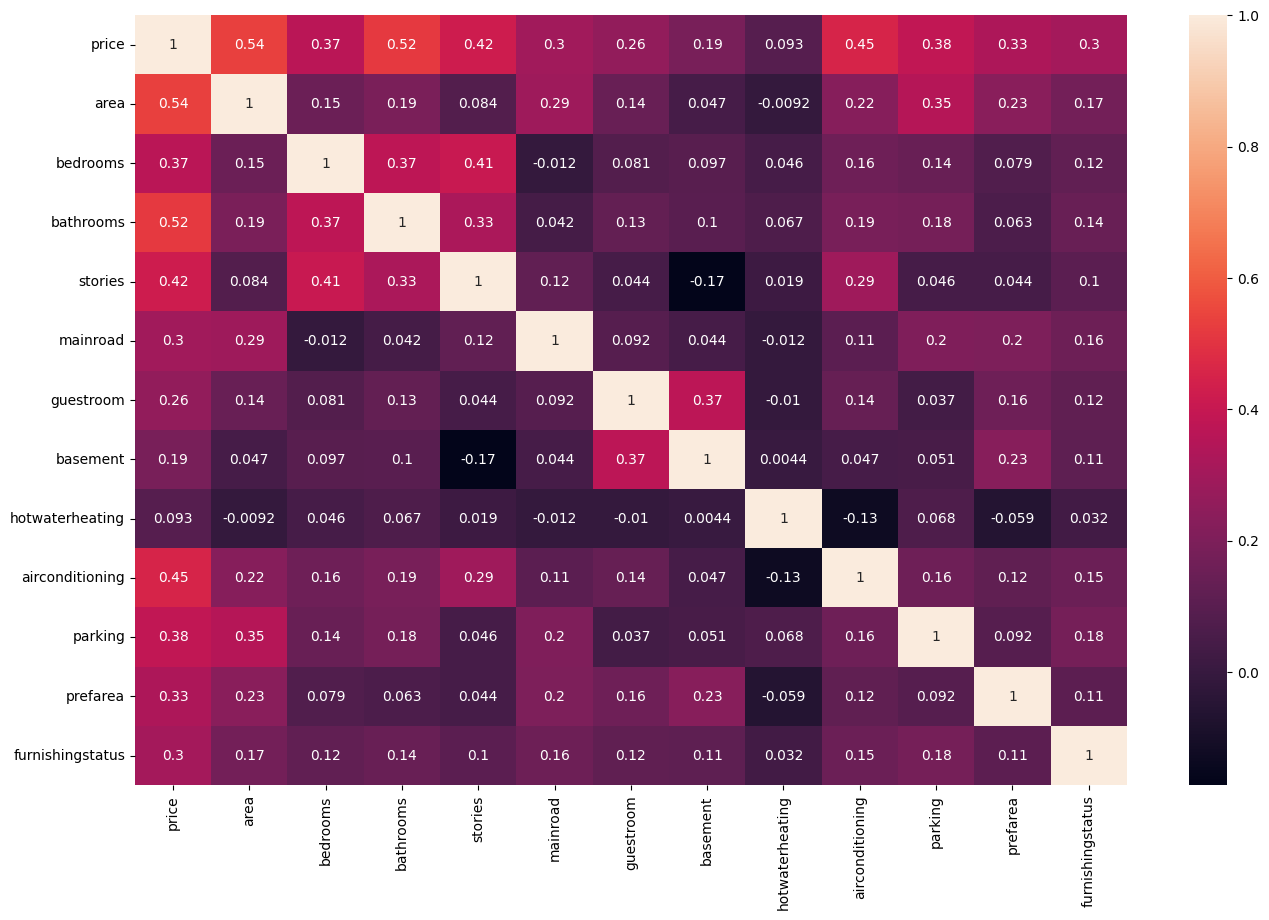

In [ ]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
x=df.drop(['price'],axis=1)
y=df['price']
x.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,2
1,8960,4,4,4,1,0,0,0,1,3,0,2
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,2
4,7420,4,1,2,1,1,1,0,1,2,0,2


In [ ]:
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 702)
print(x_train.shape)
print(x_test.shape)

(436, 12)
(109, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)


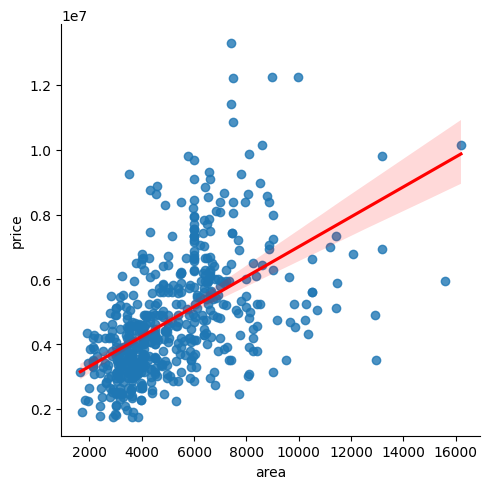

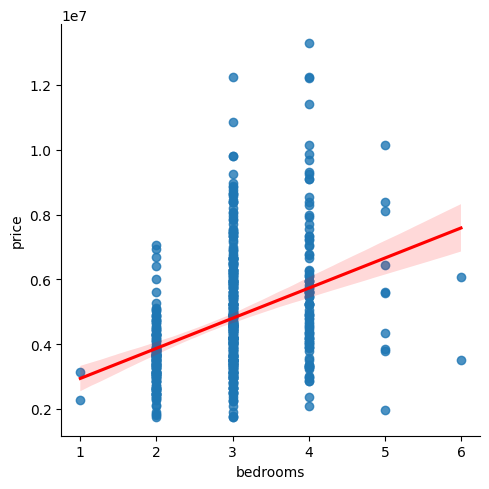

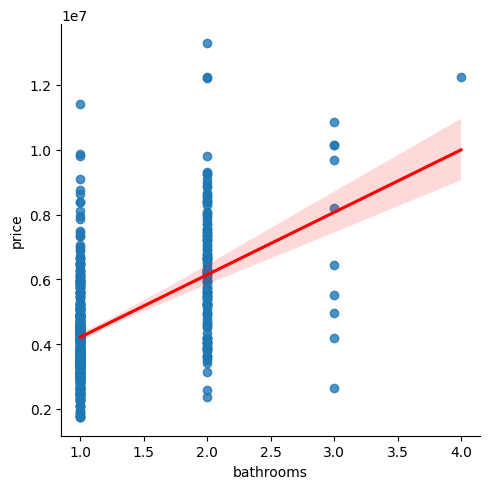

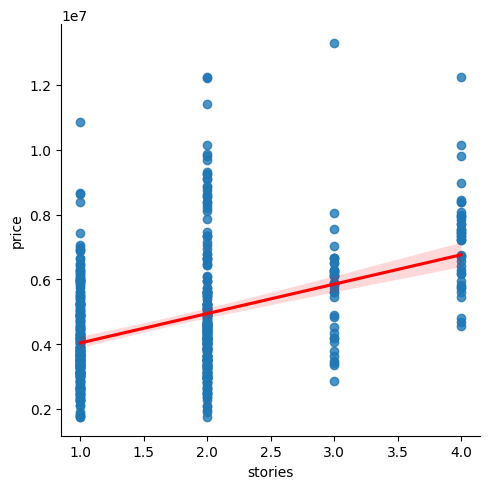

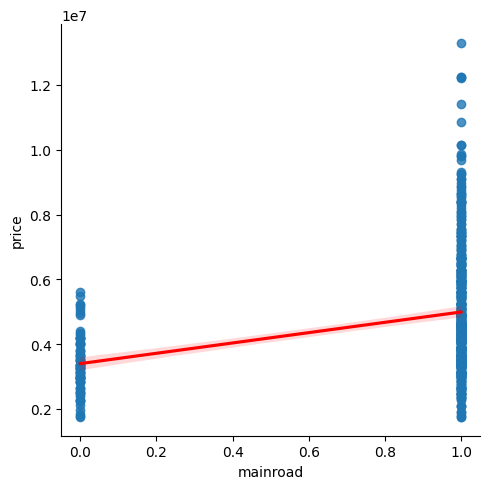

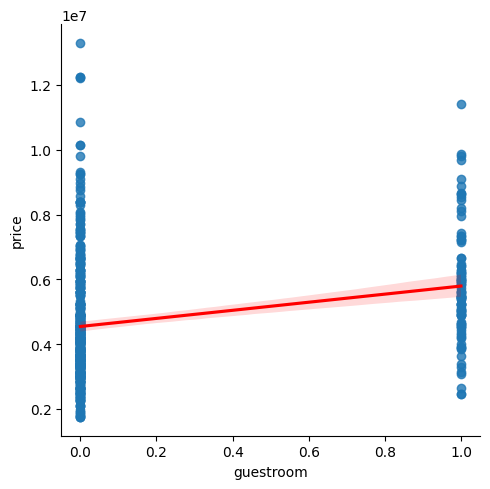

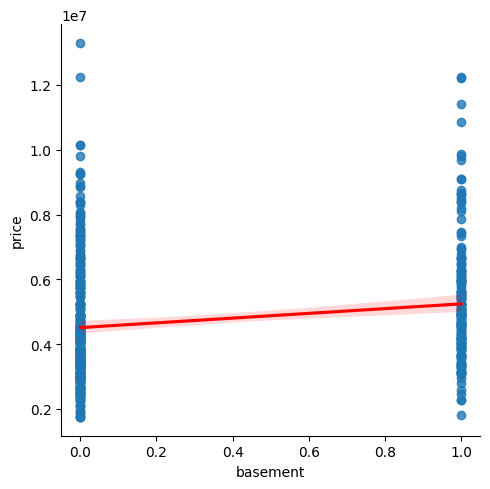

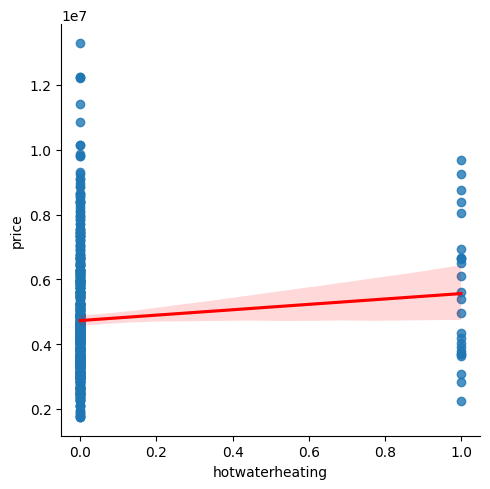

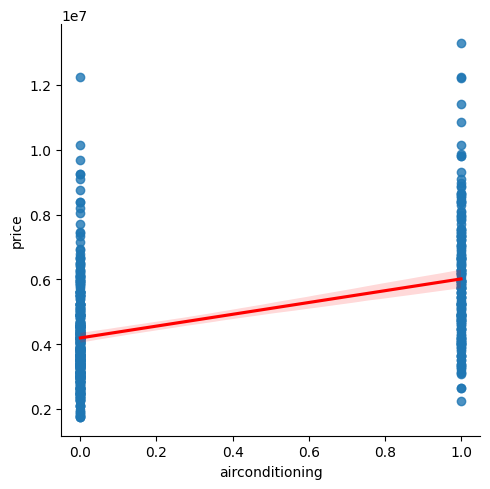

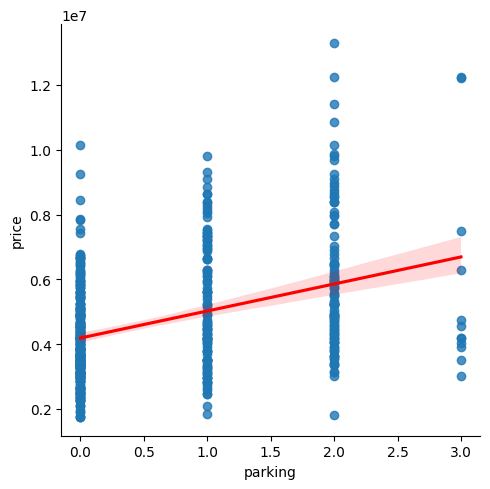

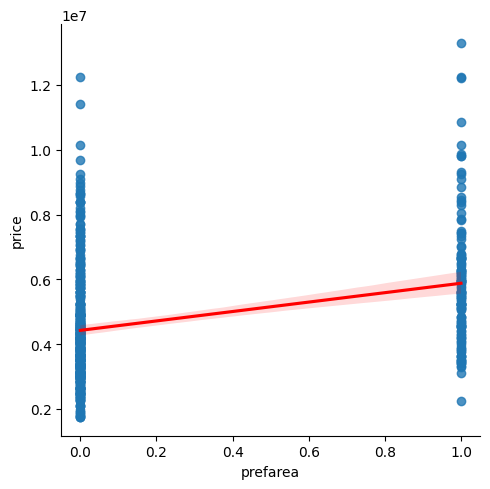

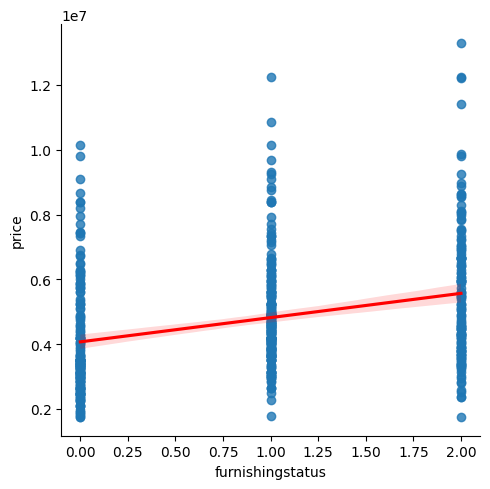

In [ ]:
#visualization
columns = x.columns
for i in columns:
  sns.lmplot(x=i,y="price",data = df,line_kws={'color':'red'})

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 1333643293900.3047
R-squared (R2): 0.6933648965370701


In [ ]:
# prompt: use different svm model kernels to predict house price and show accuracy of each

from sklearn.svm import SVR
from sklearn.metrics import accuracy_score

# Assuming x_train, x_test, y_train, y_test are already defined from your previous code

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
  svm_model = SVR(kernel=kernel)
  svm_model.fit(x_train, y_train)
  y_pred = svm_model.predict(x_test)

  # For regression tasks, accuracy is not the best metric.
  # We can use R2 score or MSE as mentioned in the previous code.
  r2 = r2_score(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)

  print(f"Kernel: {kernel}")
  print(f"R-squared (R2): {r2}")
  print(f"Mean Squared Error (MSE): {mse}")
  print("-" * 20)

Kernel: linear
R-squared (R2): -0.018299866563540323
Mean Squared Error (MSE): 4428875796949.386
--------------------
Kernel: poly
R-squared (R2): -0.018914007274340117
Mean Squared Error (MSE): 4431546869606.167
--------------------
Kernel: rbf
R-squared (R2): -0.018919829722095827
Mean Squared Error (MSE): 4431572193087.777
--------------------
Kernel: sigmoid
R-squared (R2): -0.018890401666035617
Mean Squared Error (MSE): 4431444202100.528
--------------------
